SWC Lab meeting plots:
- diff in prediction accuracy bars, sessions and mouse averages
- diff in prediction accuracy first and second half
- diff in prediction accuracy first and second half but for the first session

Supplementary:
- pred.acc. diff over sessions
- pred acc. diff top to bottom of arena

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

In [9]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features, extract_pa_across_sesh

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\SWClabmeeting"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

In [4]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

In [5]:
"""Mouse averages"""
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_pa = {}
for key in pa.keys():
    if key not in m_pa:
        m_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(all_angles):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_pa[a][m_idx,:] = np.mean(pa[a][this_mouse,:], axis=0)

In [39]:
experiments_objects[25]

Experiment(nick_name='JAL008', total_sessions=9, mouse_number_pyrat='BAA-1104291', experiment_file_names=None, root_path=WindowsPath('JAL008'), experiment_name='flip', experiment_idx=7, experiment_date='2024_05_14', experiment_time='10_18_03', experiment_path=WindowsPath('JAL008_shelter_barrier_flip_5_2024_05_14T10_18_03'), shelter_time=[0.25, -1], barrier_time=[70, -1], barrier_flip_time=197.6)

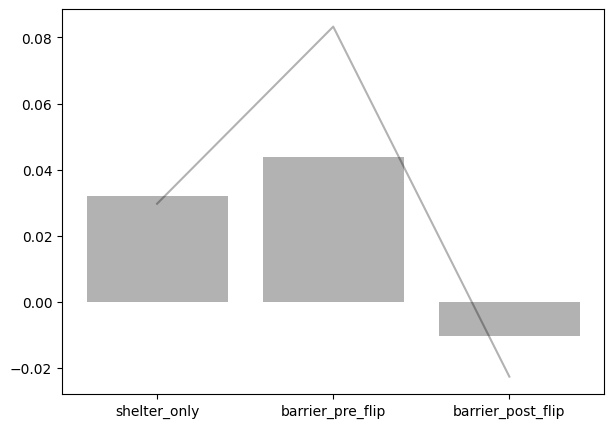

In [38]:
c = ['h_preflipbar_a','h_postflipbar_a']
# good = [0, 7, 9, 14, 19,22,25]
fig, axs = plt.subplots(1,1,figsize = (7,5))
diff = pa[c[0]] - pa[c[1]]
p = diff[25,:]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
axs.plot(conditions,p,color = 'k',alpha = .3)

In [ ]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']

fig, axs = plt.subplots(1,1,figsize = (7,5))

diff = pa[c[0]] - pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
for p in diff:
    axs.plot(conditions,p,color = 'k',alpha = .3)
axs.plot([-.5,2.5],[0,0],'--k')
axs.set_title(c[0] + ' - ' + c[1]  +  
                    '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                    '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                    fontsize = 10)
diff = m_pa[c[0]] - m_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 3, label = unique_mouse[m])
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(conditions,rotation = 45, ha="right")
axs.set_ylim([-.15,.15])
axs.set_ylabel('diff in prediction accuracy')
axs.legend(loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'.png'))